In [27]:
import sys
import os
import numpy as np
import torch
from torch.utils.data import DataLoader, Subset
from sklearn.model_selection import train_test_split
from scipy.stats import pearsonr

In [28]:
project_root = os.path.abspath("..")
if project_root not in sys.path:
    sys.path.insert(0, project_root)

In [ ]:
from kszcnn.simplified_model_comparison import *

In [ ]:
np.random.seed(SEED)
torch.manual_seed(SEED)

In [46]:
print(f"\nTrain realization: {TRAIN_REAL_IDX}")
print(f"Test realization:  {TEST_REAL_IDX}")


Train realization: 0
Test realization:  14


In [48]:
results = []
all_results = {}  

for mode in INPUT_MODES:

    rms_true, rms_lin, rms_cnn, rmse_lin, rmse_cnn, true, vlin, preds = \
        run_experiment(mode, TRAIN_REAL_IDX, TEST_REAL_IDX)

    #  table 
    results.append({
        "Model": mode,
        "RMS_true": rms_true,
        "RMS_lin":  rms_lin,
        "RMS_pred": rms_cnn,
        "RMSE_lin": rmse_lin,
        "RMSE_CNN": rmse_cnn
    })

    #  plotting 
    all_results[mode] = {
        "true": true,
        "pred": preds
    }


Running model: density
Selected halos: 547
Selected halos: 569
Epoch 1: Train=3.170e-01 | Val=5.044e-01
Epoch 2: Train=2.314e-01 | Val=4.278e-01
Epoch 3: Train=2.072e-01 | Val=3.479e-01
Epoch 4: Train=1.971e-01 | Val=3.963e-01
Epoch 5: Train=1.943e-01 | Val=3.879e-01
Epoch 6: Train=1.898e-01 | Val=3.221e-01
Epoch 7: Train=1.904e-01 | Val=4.575e-01
Epoch 8: Train=1.856e-01 | Val=3.094e-01
Epoch 9: Train=1.784e-01 | Val=3.122e-01
Epoch 10: Train=1.734e-01 | Val=2.898e-01
Epoch 11: Train=1.799e-01 | Val=3.184e-01
Epoch 12: Train=1.656e-01 | Val=3.208e-01
Epoch 13: Train=1.652e-01 | Val=2.790e-01
Epoch 14: Train=1.628e-01 | Val=3.824e-01
Epoch 15: Train=1.803e-01 | Val=3.500e-01
Epoch 16: Train=1.577e-01 | Val=3.747e-01
Epoch 17: Train=1.616e-01 | Val=2.857e-01
Epoch 18: Train=1.556e-01 | Val=2.599e-01
Epoch 19: Train=1.470e-01 | Val=2.672e-01
Epoch 20: Train=1.434e-01 | Val=2.429e-01
Epoch 21: Train=1.495e-01 | Val=2.420e-01
Epoch 22: Train=1.399e-01 | Val=2.659e-01
Epoch 23: Train=1.519

In [49]:
import pandas as pd

df = pd.DataFrame(results)
print(df)

              Model  RMS_true    RMS_lin    RMS_pred  RMSE_lin   RMSE_CNN
0           density  96.79808  51.224754  107.950882   59.2766  47.831875
1       density_pos  96.79808  51.224754   95.347076   59.2766  51.478024
2  density_pos_mass  96.79808  51.224754   98.417793   59.2766  41.361862
3          pos_mass  96.79808  51.224754   90.001633   59.2766  63.567661
4               pos  96.79808  51.224754   95.704033   59.2766  62.512798


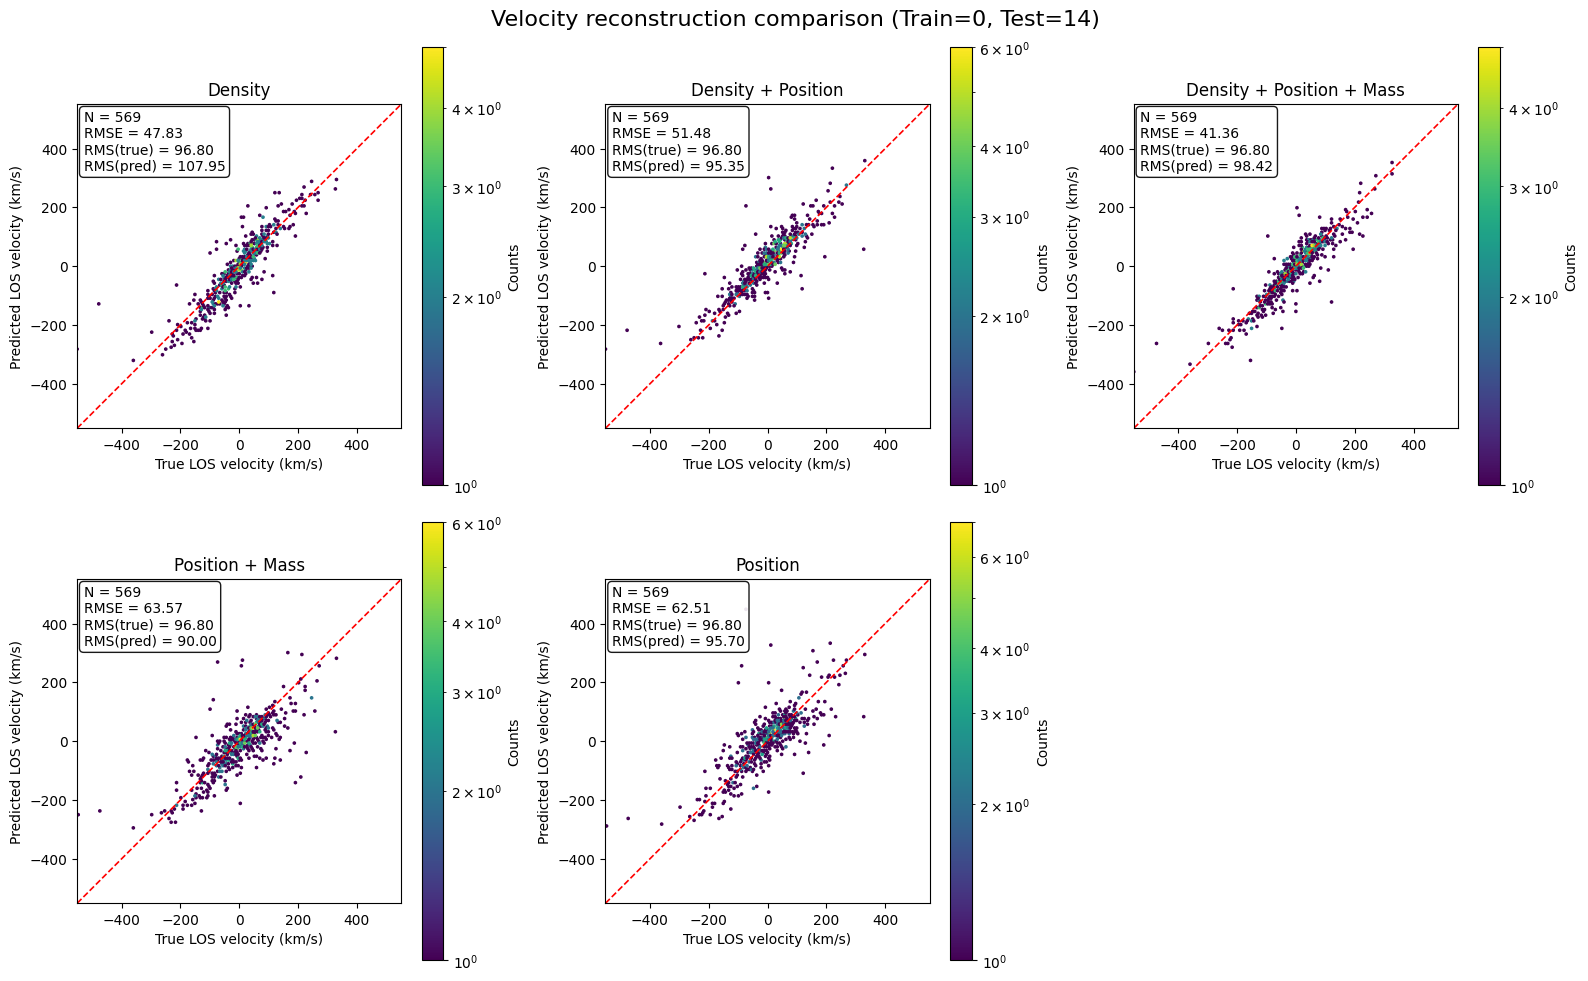

In [53]:
#  comparison plots

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

#  global limits
global_max = 0
for mode in all_results:
    t = all_results[mode]["true"]
    p = all_results[mode]["pred"]
    global_max = max(global_max, np.max(np.abs(t)), np.max(np.abs(p)))

lims = [-global_max, global_max]

#  plotting 
for i, mode in enumerate(INPUT_MODES):

    true = all_results[mode]["true"]
    preds = all_results[mode]["pred"]

    hb = hexbin_panel(
        axes[i],
        true,
        preds,
        title=MODEL_TITLES[mode],
        lims=lims
    )

    cb = fig.colorbar(hb, ax=axes[i])
    cb.set_label("Counts")

# remove unused panel
fig.delaxes(axes[-1])

plt.suptitle(
    f"Velocity reconstruction comparison (Train={TRAIN_REAL_IDX}, Test={TEST_REAL_IDX})",
    fontsize=16
)

plt.tight_layout()
plt.savefig("velocity_recons_comparison.png")
plt.show()

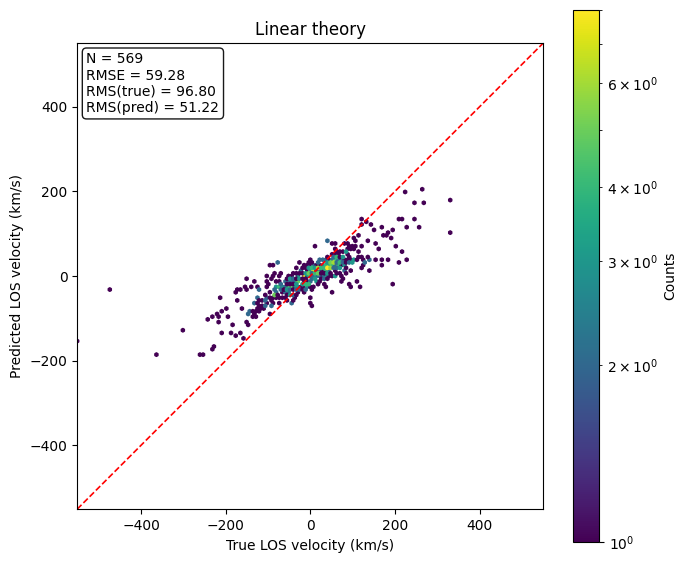

In [62]:
fig, ax = plt.subplots(figsize=(7, 6))

# global limits
vmax = max(np.max(np.abs(true)), np.max(np.abs(vlin)))
lims = [-vmax, vmax]

# hexbin 
hb = hexbin_panel(
    ax,
    true,
    vlin,
    title="Linear theory",
    lims=lims
)

#  colorbar 
cb = fig.colorbar(hb, ax=ax)
cb.set_label("Counts")

plt.tight_layout()
plt.savefig("velocity_recons_vlin_true_comp.png")
plt.show()